There are multiple lenses to look at food consumption and it's effects / correlations. You would expect some metrics to be
correlated and try to model from there.

Countries of interest for me here are Japan, France, UK, US, Germany owing to high availaibility but some specific analysis might need others.

# Supply of calories per person

This is not an actual consumption metric, but I would believe it to be highly correlated. Per capita, how much calories were available for consumption.

FAOSTAT changed its Food Balance methodology in 2010. The series below uses Our World in Data's combination of the old and new FAOSTAT datasets. Restricting it to 1961 onward keeps the source consistently FAOSTAT. The common period for all five countries is 1961–2022.

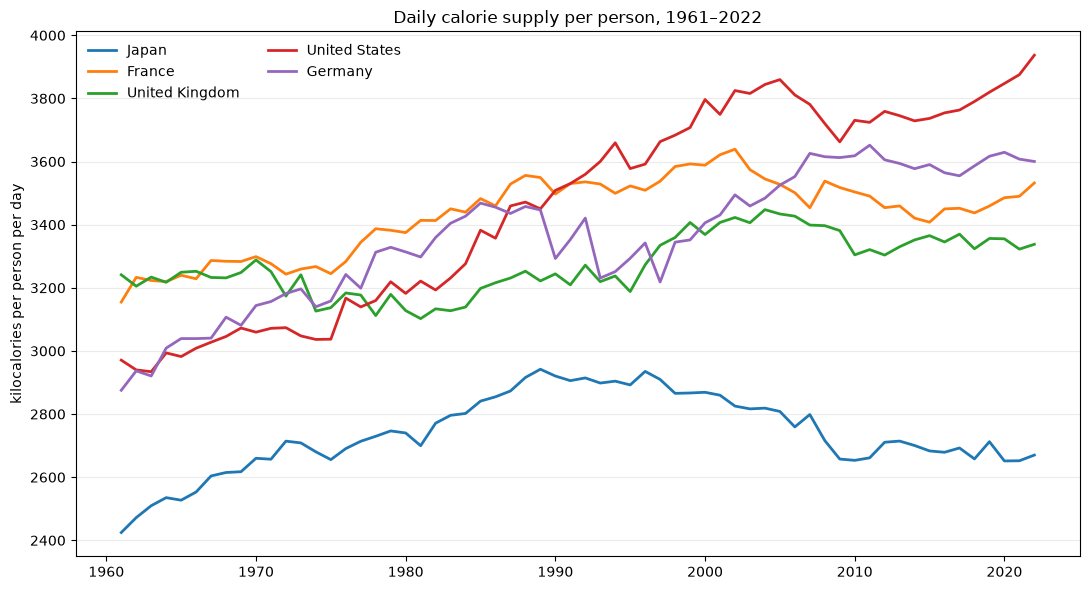

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

countries = ["Japan", "France", "United Kingdom", "United States", "Germany"]
url = "https://ourworldindata.org/grapher/daily-per-capita-caloric-supply.csv?v=1&csvType=full&useColumnShortNames=false"

calories = pd.read_csv(
    url, storage_options={"User-Agent": "food-intake-analysis/0.1"}
)
calories = (
    calories.loc[calories["Entity"].isin(countries) & calories["Year"].ge(1961)]
    .pivot(index="Year", columns="Entity", values="Daily calorie supply per person")
    .dropna(subset=countries)
)
assert list(calories.columns.sort_values()) == sorted(countries)
assert calories.index.is_monotonic_increasing and not calories.empty

ax = calories[countries].plot(figsize=(11, 6), linewidth=2)
ax.set(
    title=f"Daily calorie supply per person, {calories.index.min()}–{calories.index.max()}",
    xlabel="",
    ylabel="kilocalories per person per day",
)
ax.grid(axis="y", alpha=0.25)
ax.legend(title=None, ncol=2, frameon=False)
plt.tight_layout()
plt.savefig("calorie-supply.png", dpi=180, bbox_inches="tight")
plt.show()

Japan once again an outlier, you could argue

# Obesity rates

France is an interesting case while I'm not at all surprised by Japan here.
Every country has such programmes and I cannot quite ascertain if it was indeed because of that but ChatGPT does refer to Programme National Nutrition Santé (PNNS)
as being one of the possible reasons.

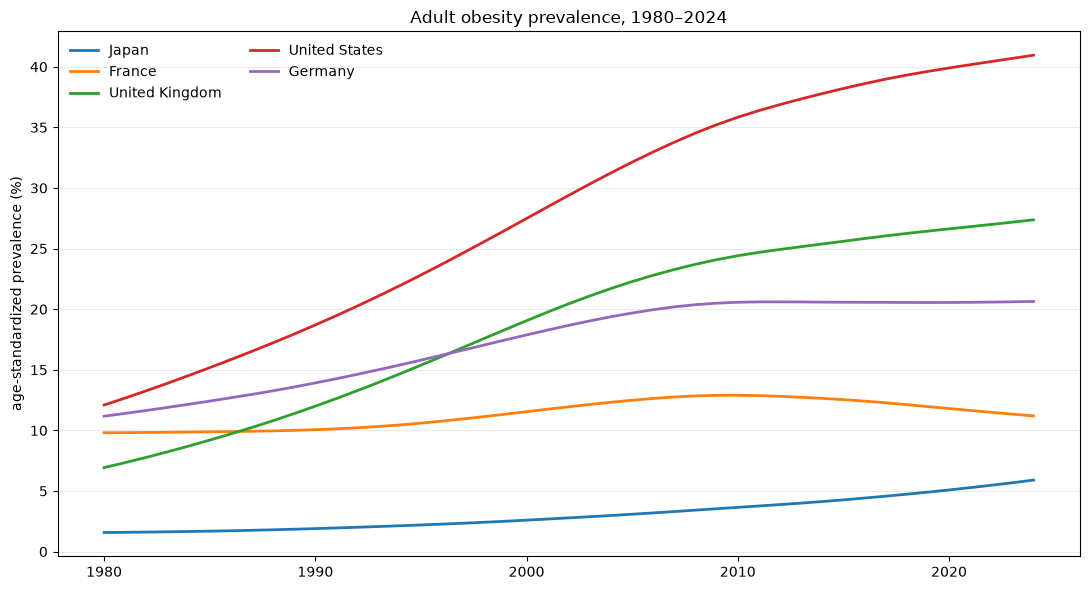

In [3]:
obesity_url = "https://ourworldindata.org/grapher/obesity-prevalence-adults-who-gho.csv?v=1&csvType=full&useColumnShortNames=false"
obesity_raw = pd.read_csv(
    obesity_url, storage_options={"User-Agent": "food-intake-analysis/0.1"}
)
obesity = (
    obesity_raw.loc[obesity_raw["Entity"].isin(countries)]
    .pivot(index="Year", columns="Entity", values=obesity_raw.columns[-1])
    .dropna(subset=countries)
)
assert list(obesity.columns.sort_values()) == sorted(countries)
assert obesity.index.is_monotonic_increasing and not obesity.empty

ax = obesity[countries].plot(figsize=(11, 6), linewidth=2)
ax.set(
    title=f"Adult obesity prevalence, {obesity.index.min()}–{obesity.index.max()}",
    xlabel="",
    ylabel="age-standardized prevalence (%)",
)
ax.grid(axis="y", alpha=0.25)
ax.legend(title=None, ncol=2, frameon=False)
plt.tight_layout()
plt.savefig("obesity-rates.png", dpi=180, bbox_inches="tight")
plt.show()

# Lagged correlation

To reduce correlation caused by both series trending over time, this compares annual changes rather than raw levels. Lag 0 compares changes in the same year; lag 5 compares a calorie-supply change with the obesity-rate change five years later. Pearson correlation does not establish causation.

In [ ]:
lag_years = range(11)
calorie_changes = calories.diff()
obesity_changes = obesity.diff()
lag_correlations = pd.DataFrame(
    {
        country: [
            calorie_changes[country].shift(lag).corr(obesity_changes[country])
            for lag in lag_years
        ]
        for country in countries
    },
    index=lag_years,
)
assert lag_correlations.notna().all().all()

ax = lag_correlations[countries].plot(figsize=(11, 6), marker="o", linewidth=2)
ax.axhline(0, color="black", linewidth=1, alpha=0.5)
ax.set(
    title="Correlation of annual changes at different delays",
    xlabel="delay after calorie-supply change (years)",
    ylabel="Pearson correlation (r)",
    xticks=list(lag_years),
)
ax.grid(axis="y", alpha=0.25)
ax.legend(title=None, ncol=2, frameon=False)
plt.tight_layout()
plt.savefig("lagged-correlations.png", dpi=180, bbox_inches="tight")
plt.show()